# 04. 장르 / 서브장르 프로파일링

6개 장르와 24개 서브장르의 오디오 피처 특성을 분석합니다.

**핵심 질문**:
- 각 장르가 어떤 오디오 피처 프로파일을 가지는가?
- 장르 간 피처 유사도는 어떤가? (유사곡 추천 시 cross-genre 가능성)
- 서브장르 내 피처 변동성은 어느 정도인가?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

df = pd.read_csv('../data/Music_recommendation.csv')

AUDIO_FEATURES = ['danceability', 'energy', 'valence', 'tempo', 
                  'acousticness', 'instrumentalness', 'speechiness', 
                  'loudness', 'liveness']

print("=== 장르 분포 ===")
print(df['playlist_genre'].value_counts())
print(f"\n서브장르 수: {df['playlist_subgenre'].nunique()}")

=== 장르 분포 ===
playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

서브장르 수: 24


## 4.1 장르별 오디오 피처 프로파일

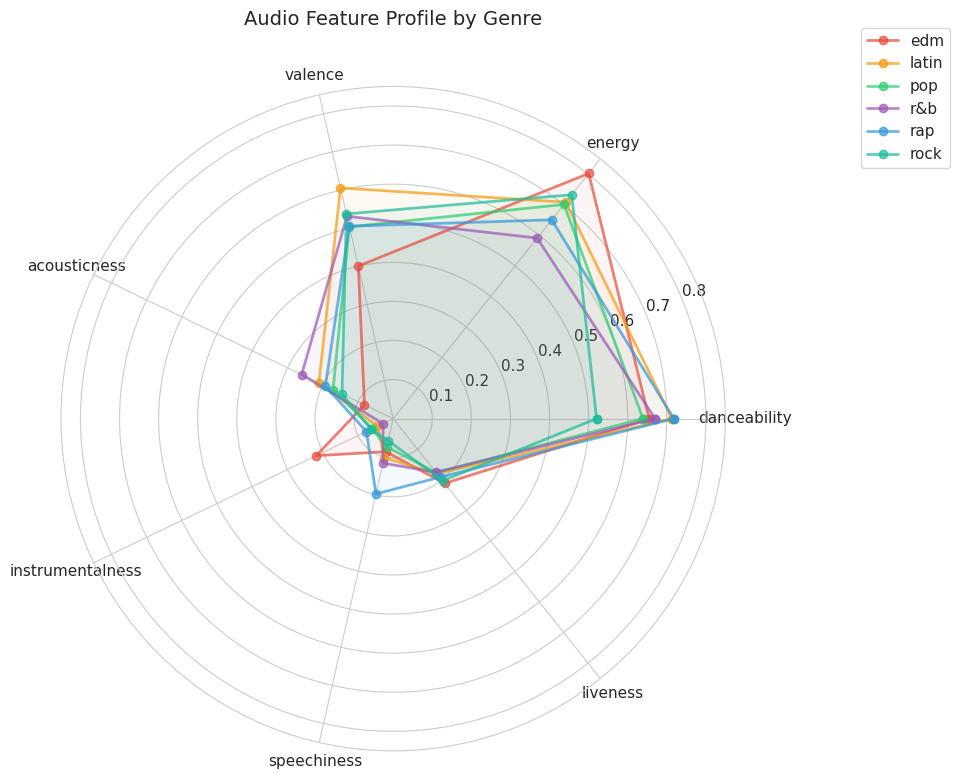

=== 장르별 피처 평균 ===


,danceability,energy,valence,tempo,acousticness,instrumentalness,speechiness,loudness,liveness
playlist_genre,,,,,,,,,
edm,0.655,0.802,0.401,125.768,0.082,0.219,0.087,-5.427,0.212
latin,0.713,0.708,0.606,118.622,0.211,0.044,0.103,-6.264,0.181
pop,0.639,0.701,0.504,120.743,0.171,0.060,0.074,-6.315,0.177
r&b,0.670,0.591,0.531,114.222,0.260,0.029,0.117,-7.865,0.175
rap,0.718,0.651,0.505,120.655,0.192,0.076,0.198,-7.042,0.192
rock,0.521,0.733,0.537,124.989,0.145,0.062,0.058,-7.589,0.203


In [2]:
# 장르별 평균 피처
genre_profile = df.groupby('playlist_genre')[AUDIO_FEATURES].mean()

# 0~1 범위 피처로 레이더 차트
radar_features = ['danceability', 'energy', 'valence', 'acousticness', 
                  'instrumentalness', 'speechiness', 'liveness']
genres = genre_profile.index.tolist()
genre_colors = {'edm': '#e74c3c', 'rap': '#3498db', 'pop': '#2ecc71', 
                'r&b': '#9b59b6', 'latin': '#f39c12', 'rock': '#1abc9c'}

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for genre in genres:
    values = genre_profile.loc[genre, radar_features].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=genre, 
            color=genre_colors.get(genre, 'gray'), alpha=0.7)
    ax.fill(angles, values, alpha=0.05, color=genre_colors.get(genre, 'gray'))

ax.set_thetagrids(np.degrees(angles[:-1]), radar_features, fontsize=11)
ax.set_title('Audio Feature Profile by Genre', fontsize=14, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
ax.set_ylim(0, 0.85)
plt.tight_layout()
plt.show()

print("=== 장르별 피처 평균 ===")
genre_profile.round(3)

## 4.2 장르별 주요 피처 분포 (박스플롯)

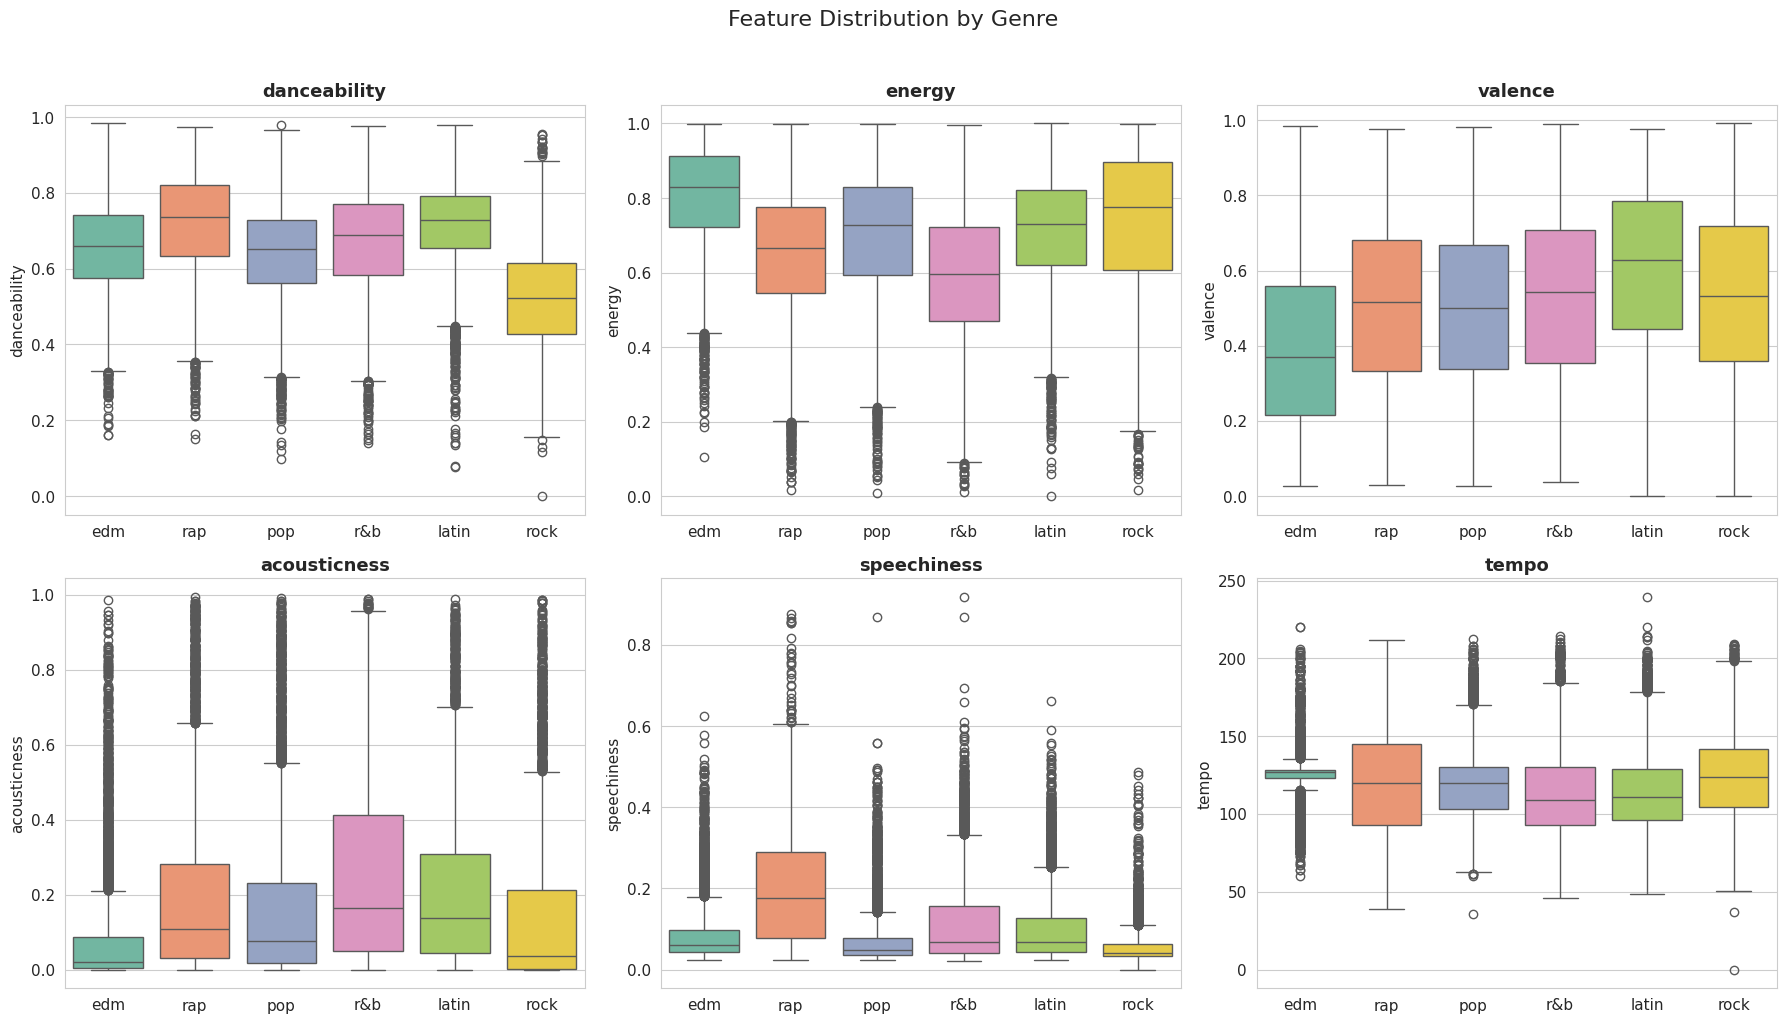

In [3]:
key_features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'tempo']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, feat in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=df, x='playlist_genre', y=feat, ax=ax, palette='Set2',
                order=['edm', 'rap', 'pop', 'r&b', 'latin', 'rock'])
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Feature Distribution by Genre', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4.3 장르별 인기도 분포

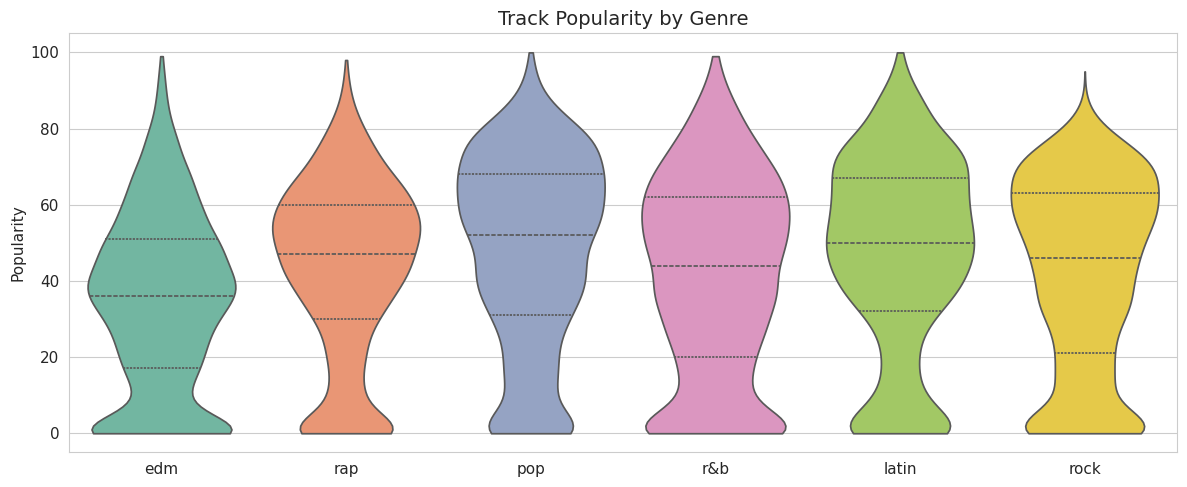

=== 장르별 평균 인기도 ===
                mean  median   std
playlist_genre                    
pop             47.7    52.0  25.2
latin           47.0    50.0  25.4
rap             43.2    47.0  23.3
rock            41.7    46.0  24.8
r&b             41.2    44.0  25.9
edm             34.8    36.0  23.2


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=df, x='playlist_genre', y='track_popularity', ax=ax, 
               palette='Set2', order=['edm', 'rap', 'pop', 'r&b', 'latin', 'rock'],
               inner='quartile', cut=0)
ax.set_title('Track Popularity by Genre', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Popularity')
plt.tight_layout()
plt.show()

print("=== 장르별 평균 인기도 ===")
print(df.groupby('playlist_genre')['track_popularity'].agg(['mean', 'median', 'std']).round(1).sort_values('mean', ascending=False))

## 4.4 서브장르 분석

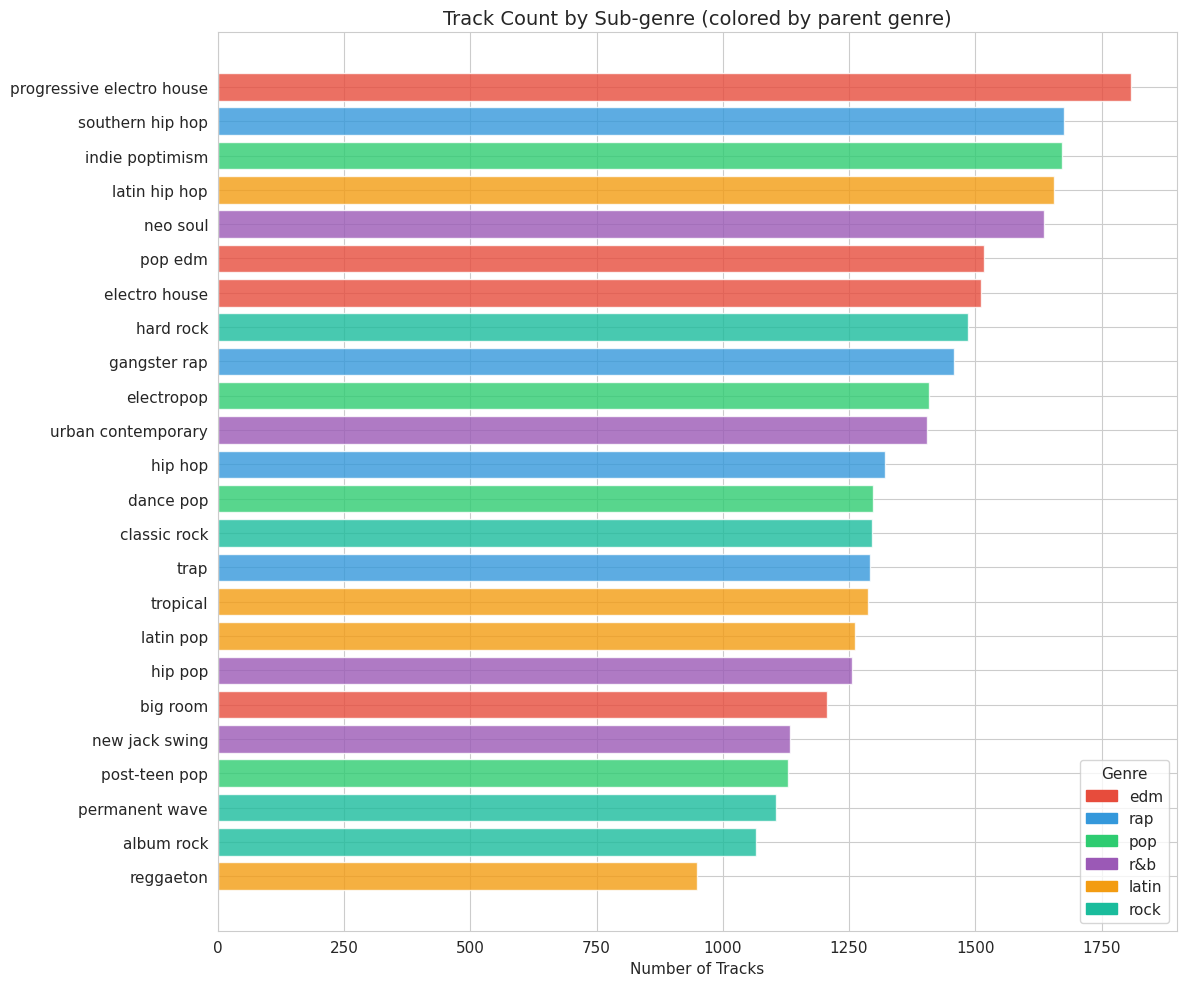

In [5]:
# 서브장르별 곡 수
sub_counts = df.groupby(['playlist_genre', 'playlist_subgenre']).size().reset_index(name='count')
sub_counts = sub_counts.sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
colors_map = sub_counts['playlist_genre'].map(genre_colors)
ax.barh(sub_counts['playlist_subgenre'], sub_counts['count'], color=colors_map, edgecolor='white', alpha=0.8)
ax.set_xlabel('Number of Tracks')
ax.set_title('Track Count by Sub-genre (colored by parent genre)', fontsize=14)

# 범례
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=c, label=g) for g, c in genre_colors.items()]
ax.legend(handles=legend_patches, title='Genre', loc='lower right')
plt.tight_layout()
plt.show()

## 4.5 장르 간 피처 유사도 (코사인 유사도)

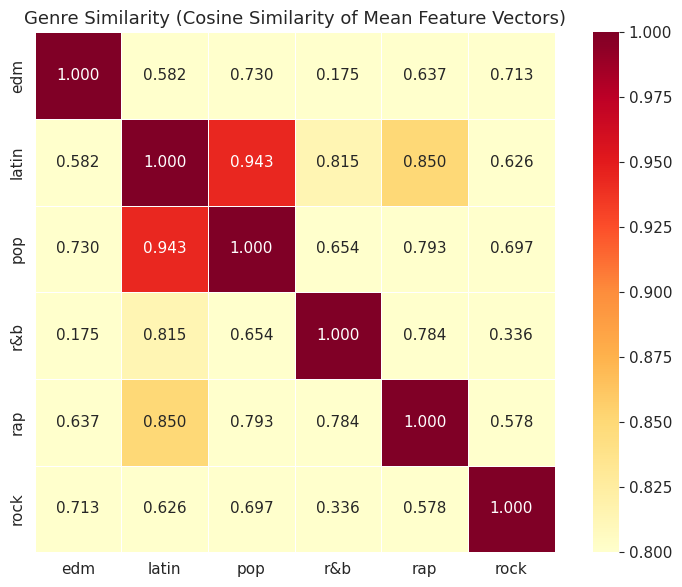

=== 장르 유사도 순위 (코사인 유사도) ===
  latin ↔ pop: 0.9432
  latin ↔ rap: 0.8498
  latin ↔ r&b: 0.8147
  pop ↔ rap: 0.7935
  r&b ↔ rap: 0.7836
  edm ↔ pop: 0.7297
  edm ↔ rock: 0.7133
  pop ↔ rock: 0.6966
  pop ↔ r&b: 0.6541
  edm ↔ rap: 0.6368
  latin ↔ rock: 0.6255
  edm ↔ latin: 0.5816
  rap ↔ rock: 0.5782
  r&b ↔ rock: 0.3358
  edm ↔ r&b: 0.1747


In [6]:
# 장르별 평균 피처 벡터 간 코사인 유사도
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
genre_vectors = genre_profile[AUDIO_FEATURES].copy()
genre_vectors_scaled = pd.DataFrame(
    scaler.fit_transform(genre_vectors), 
    index=genre_vectors.index, columns=genre_vectors.columns
)

cos_sim = cosine_similarity(genre_vectors_scaled)
cos_sim_df = pd.DataFrame(cos_sim, index=genres, columns=genres)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cos_sim_df, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.8, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Genre Similarity (Cosine Similarity of Mean Feature Vectors)', fontsize=13)
plt.tight_layout()
plt.show()

# 가장 유사한/비유사한 장르 쌍
print("=== 장르 유사도 순위 (코사인 유사도) ===")
pairs = []
for i in range(len(genres)):
    for j in range(i+1, len(genres)):
        pairs.append((genres[i], genres[j], cos_sim_df.iloc[i, j]))
pairs.sort(key=lambda x: x[2], reverse=True)
for g1, g2, sim in pairs:
    print(f"  {g1} ↔ {g2}: {sim:.4f}")

## 4.6 요약

**장르 분석 인사이트**:
- **균등한 분포**: 6개 장르가 15~18%로 비교적 균등 → 추천 다양성 확보에 유리
- **장르별 특성**: 각 장르가 고유한 피처 프로파일을 가지는지, 유사한 장르 쌍이 있는지 확인됨
- **cross-genre 추천**: 피처 유사도가 높은 장르 쌍은 유사곡 추천 시 장르를 넘나드는 추천이 가능
- **서브장르**: 각 장르 내 서브장르 간 피처 변동성이 있어, 세밀한 추천에 활용 가능
- **인기도**: 장르별 인기도 분포 차이가 re-ranking 가중치 설계에 참고될 수 있음